<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>                                                                         <center><h1></h1></center>
<h1><left> <font size=5>MLS 6: Introduction to Agents</font></left></h1>

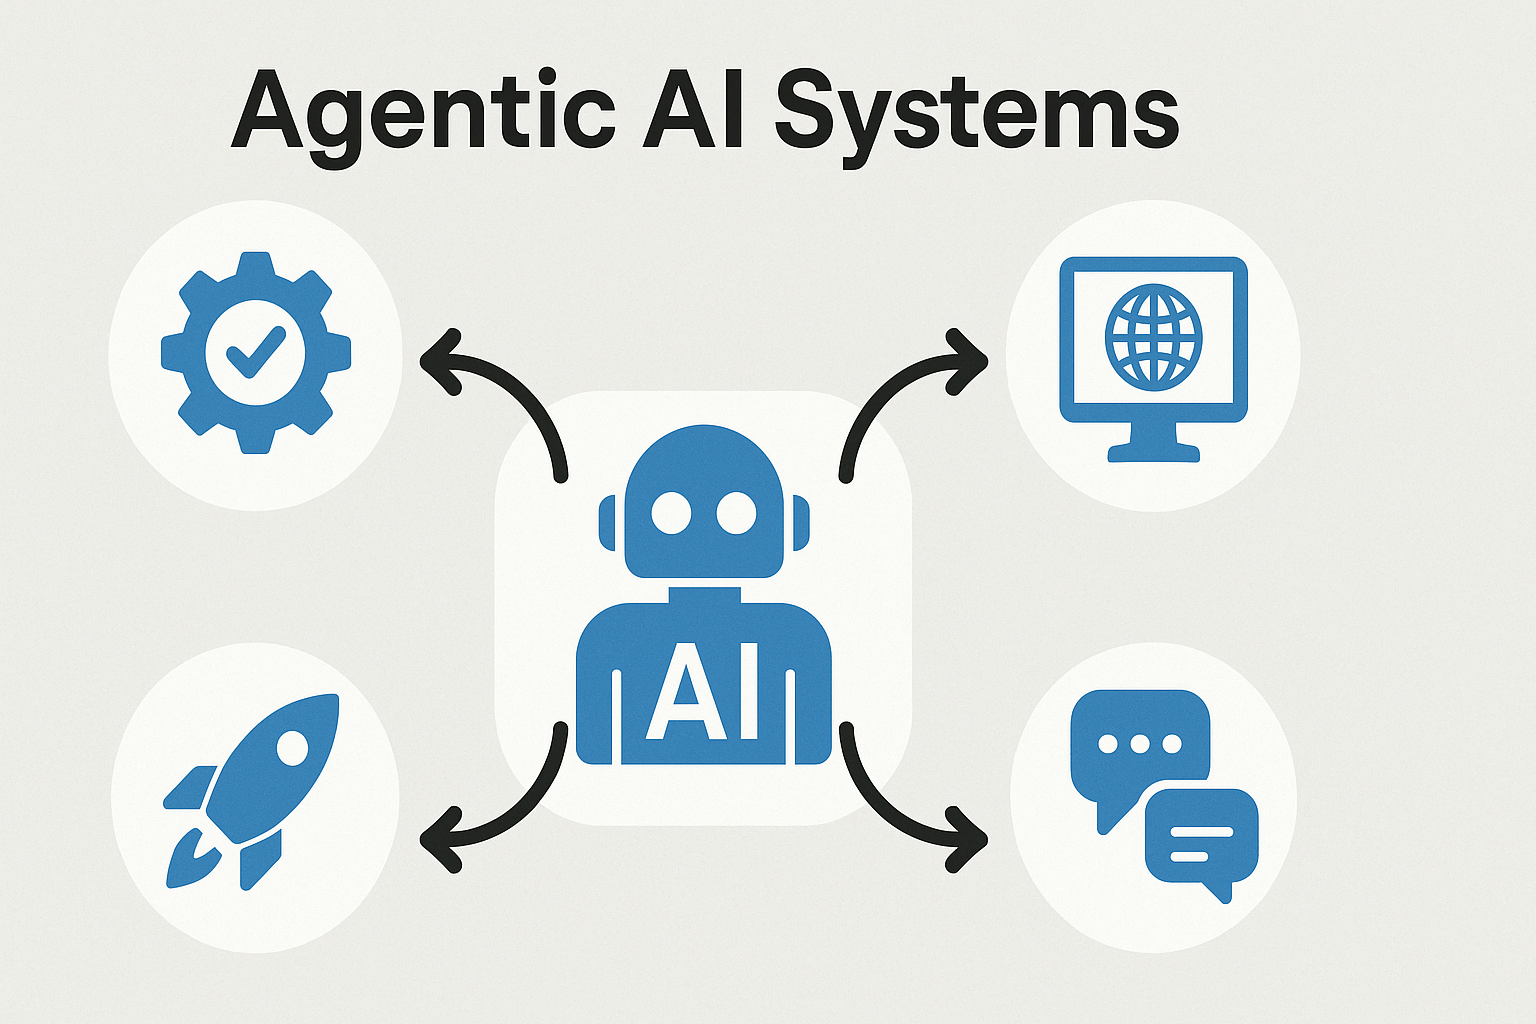

# Business Context

## Automated Programming Assessments Using GenAI Workflow

**Problem Scenario:**

The EdTech division of a leading financial services company seeks to modernize its employee and client training programs & processes.

Currently, this assessment process is resource-intensive and time-consuming, involving the manual creation of topic-specific programming questions, development of comprehensive test cases, evaluation of learners' code submissions, and provision of tailored feedback, ranging from pass/fail results to guidance on improvement areas.

This manual approach is prone to delays and challenging to scale for large-scale training programs serving hundreds of learners monthly in multiple batches.

Furthermore, the existing process has an average assessment delivery time of 5-7 days, a 15% error rate in evaluations, and high operational costs, hindering the division's ability to deliver timely, high-quality, and personalized training at scale.

Hence, there is a need to automate this entire workflow in order to reduce assessment delivery time and resource expenditure while maintaining assessment quality and personalization.

# Objective

**Proposed Solution:**

The solution proposed is to streamline and automate the programming assessment process by streamlining question generation, test case creation, and solution evaluation through modular GenAI workflows.

The solution comprises three modular components, each leveraging distinct design patterns — sequential, parallelization, and compositional that can operate independently as well as cohesively.

1. **Question Generation Module**:Given a programming topic, the module will generates multiple distinct questions with varying complexity, while avoiding redundancy.

  Question generation is step-by-step and typically follows this workflow: `Question Generation` ➡️ `Question Validation`

  Since the workflow is well-defined, we'll use a **Sequential Pattern**


2. **Test Case Generation Module**: For given Python question, this module  will create a comprehensive set of test cases encompassing multiple scenarious such as standard scenarios, edge cases, and error cases.

  A **parallelization pattern** will work best for this module since given a question, each testcase type can be generated independently by specialized agents oeprating in parallel, reducing latency, and ensuring thorough coverage.

3. **Evaluation & Feedback Module**: This module will evaluate the learner's submissions against the generated test cases and then provide feedback based on evaluation criteria.

  This module will utilize a **conditional pattern** to first evaluate the user response and proceeds to the subsequent criteria (success_feedback/ improvement feedback) based on a simple pass/fail criterion.

The workflow implementations will demonstrate the utility of different agentic design patterns using the popular AI Orchestration framework, LangGraph.

# Installing and Importing the Necessary Libraries

In this section, we install and import libraries required to run the notebook:

- The `openai` package provides the official OpenAI API client for accessing models like GPT-4, Whisper, DALL·E, including its embedding models

- LangChain is a GenAI framework to build applications with LLMs using chains and agents.
  - `langchain` is the core library that provides access to various LangChain abstractions
  - `langchain-openai` module provides a plug-in interface for LangChain to call OpenAI's LLMs using standardized interface.
  - `langchain-experimental` module is an extension of the core langchain framework that provides experimental modules and tools for cutting-edge use cases
  - `langgraph` is a framework for building stateful, multi-step, and multi-agent applications using graph-based workflows with Language Models (LLMs) at the core.

- `mermaid-python` is a python library that is used to generate and render diagrams and flowcharts using Mermaid.js syntax.

In [ ]:
# Installing the Libraries
!pip install -q openai==1.66.3 \
                langchain==0.3.20 \
                langchain-openai==0.3.9 \
                langgraph==0.3.21 \
                mermaid-python==0.1 \
                langchain_experimental==0.3.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.4/567.4 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.5/216.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.

In [ ]:
# Importing the Libraries
import ast
import json
from IPython.display import Image, display
from pprint import pprint
from typing import List, TypedDict, Any, List, Dict, Tuple, Annotated, Literal
from pydantic import BaseModel, Field
# Create mermaid diagrams for the graph
from mermaid import Mermaid

# Importing LangChain components
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableConfig
from langchain_experimental.tools import PythonREPLTool

# Importing LangGraph and its component nodes
from langgraph.graph import START, END, StateGraph

Setting up the OpenAI key and its configuration

In [ ]:
# Load OpenAI API Key from colab secrets
from google.colab import userdata
openai_api_key = userdata.get('openai_api_key')

In [ ]:
# LLM model
model_name = 'gpt-4o-mini'  # Lightweight, fast version of GPT-4o optimized for performance

# Instantiating the OpenAI client with the API key and base URL
llm = ChatOpenAI(
    api_key = openai_api_key,
    base_url = "https://aibe.mygreatlearning.com/openai/v1",
    model = 'gpt-4o',
    #model='gpt-4o-mini',
    temperature = 0
)

The following steps will be followed for creating the LangGraph workflows:
1. Define the State Object
2. Define the Workflow node(s)
3. Graph Construction
4. Workflow Execution



##  1. Question Generation Module (Sequential Pattern)


A sequential pattern (prompt chaining) works by creating a structured workflow chaining multiple prompts

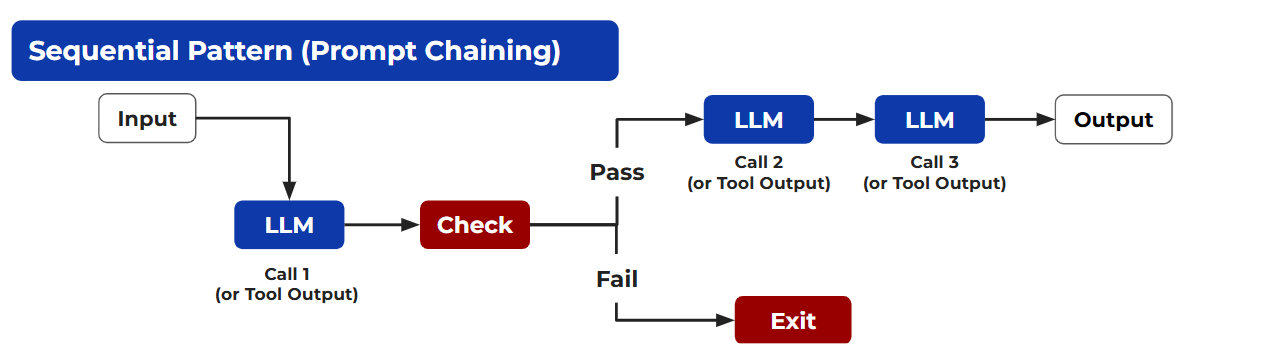

### Define State Object

Let us begin by defining our state object class to hold all the items in the workflow that we want to store using a Pydantic model.

In [ ]:
# Define the state to hold topic, number of questions and  questions generated
class QPGenerationState(BaseModel):
    topic: str = Field(description= "User-provided topic (e.g., 'Dictionaries')")
    num_questions: int = Field(description="Total questions to generate")
    questions: List[Dict[str, Any]] = Field(
        default=[],
        description="List of JSON questions generated"
    )

The class `QPGenerationState` inherits from BaseModel (a Pydantic model) for data validation and type enforcement stores the 3 workflow items:  
- The topic,
- The number of questions to generate, and
- The list of generated questions in JSON format.

### Define Workflow node


We'll define 2 nodes for the workflow:
- Question Generation node will return a question given an input topic and the number of questions to be generated
- Question Validation node will validate the questions generated by the previous node

#### Question Generation Node

This function `generate_questions` acts as a node in the workflow that takes the user input i.e. topic and number of questions (from the input state), constructs a prompt for the language model - for generate programming questions in a specific JSON format based on the provided inputs - `topic` and `number_of_questions`.

It then invokes the LLM with this prompt and attempts to parse the JSON response.

Finally, it updates the state object with the generated questions.

In [ ]:
# Node to generate questions
def generate_questions(state: QPGenerationState) -> QPGenerationState:

    print("--- GENERATING QUESTIONS FOR THE TOPIC---> " + state.topic)

    topic = state.topic
    num_questions= state.num_questions

    question_generation_system_message = f"""
    As an expert Python instructor, generate exactly {state.num_questions} distinct programming questions
    about '{topic}'.

    Return them as a list of JSON objects, each following this schema:
      - question_no: Question number (Q1, Q2, etc.)
      - problem: Problem statement starting with "Write a Python function to..."
      - sample_input: Input arguments as string (e.g. "{{{{'a': 1, 'b':2}}}}", ""XYZ"")
      - sample_output: Expected output as string(e.g. "[1,2,3]", "(1,2,3)")

    ## Requirements:
    - Each question must be unique, covering different subtopics within '{topic}'.
    - Questions must increase in difficulty from simplest (Q1) to most complex (Q{state.num_questions}).
    - Include boundary/edge cases in the problem statement.
    - Explicitly specify all invalid and error conditions in the problem statement.

    ## Prohibited:
    - No explanations or code solutions.
    - No markdown formatting (except for the JSON schema).
    - Do not truncate or omit questions.
    - Ensure exactly {state.num_questions} questions are generated.
"""

    prompt = ChatPromptTemplate.from_messages([
        ("system", question_generation_system_message),
        ("human", "Topic: {topic}, No_of_Questions: {num_questions}")
    ])

    chain = prompt | llm
    response = chain.invoke({"topic": state.topic, "num_questions": state.num_questions})

    # Parse JSON response
    print(response.content)
    try:
        questions = json.loads(response.content)
        if isinstance(questions, list) and all(isinstance(q, dict) for q in questions):
            state.questions = questions
        else:
            print("Warning: LLM response was not a list of dictionaries.")
            state.questions = []
    except json.JSONDecodeError:
        print("Error: Failed to parse LLM response as JSON.")
        state.questions = []
    except Exception as e:
        print(f"An unexpected error occurred during JSON parsing: {e}")
        state.questions = []
    print("--- QUESTIONS GENERATED ---")
    print(state.questions)
    print("------")
    return state

Using the defined function, let's generate Python programming questions on  the topic of `list comprehension`

In [ ]:
#optional test
generate_questions(QPGenerationState(topic="list comprehension", num_questions=2))

#### Question Validation Node

This function `validate_questions` simulates a validator node - it validates if the correct number of questions were generated and then updates the state with the validation result for the next steps in the workflow

If the quantity doesn't match the expected number, it flags the questions as "INVALID".

**NOTE:** Currently, it doesn't perform other checks such as ensuring if the questions are distinct.

In [ ]:
def validate_questions(state: QPGenerationState) -> QPGenerationState:

  print("--- VALIDATING GENERATED QUESTIONS ---" + state.topic)

  questions = state.questions

  if not questions:
        return {
            "question_validation": "INVALID: No question generated.",
            "error_message": "question generation failed."
        }

  # --- Validation Criteria ---
  # For this example, we will implement rule-based checks
  # we shall also use an LLM for validation.
  # LLM-based validation is more flexible but less deterministic.

  class QuestionValidation(BaseModel):
    is_valid: bool = Field(description="Whether the question meets all criteria")
    reason: str = Field(description="Reasoning for the validation decision. If invalid, explain why.")

  # 1. Check for at least num_questions * 3 lines (question, input, output per question)
  if len(questions) != state.num_questions:
      error_message = "Mismatch in number of question generated"
      print("--- GENERATED INVALID QUESTIONS ---" )
      return {
          "question_validation": "INVALID",
          "error_message": error_message
      }

  # 2. TODO:  Check if questions are distinct

  print("--- GENERATED VALID QUESTIONS ---" )
  return {
      "question_validation": "VALID",
      "error_message": ""
  }

### Graph Construction

The following code builds the end-to-end LangGraph workflow using the nodes `generate_questions` and `validate_questions` created in the previous steps.

In [ ]:
# Build the LangGraph workflow
workflow = StateGraph(QPGenerationState)

# Add nodes
workflow.add_node("generate_questions", generate_questions)
workflow.add_node("validate_questions", validate_questions)

# Define edges
workflow.set_entry_point("generate_questions")
workflow.add_edge("generate_questions", "validate_questions")

# Compile the graph
graph = workflow.compile()

The following code display a Mermaid diagram using the previously created graph object.

In [ ]:
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

### Workflow Execution

The workflow can now be executed with the `graph.invoke` method with the following parameters:
* topic = `list comprehension`
* number of questions = `2`

In [ ]:
chosen_topic = "list comprehension"
num_of_questions = 2  # Configurable number of questions
result = graph.invoke({"topic": chosen_topic,"num_questions" : num_of_questions })

In [ ]:
result

In [ ]:
# First question
result["questions"][0]

In [ ]:
question = result["questions"][0]

## 2. Test Case Generation Module (Parallelization Pattern)

In the Parallelization Pattern, independent subtasks are executed simultaneously in parallel.

A designated aggregator then integrates the individual outputs gathered from these concurrent processes.


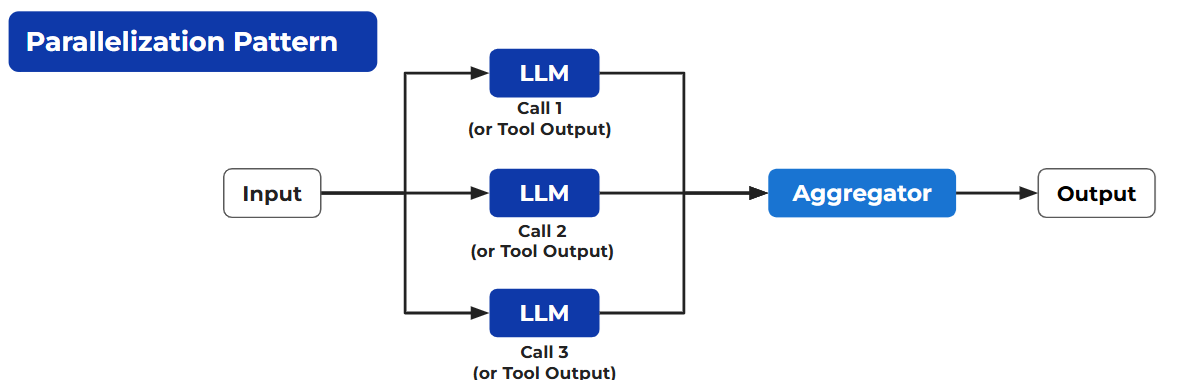

Given a Python question, the `Test Case Generation module` will utilize a parallelization pattern to generate test cases across three broad categories:
* standard scenarios,
* edge cases, and
* error cases.

### Define State Object

Below 3 state  classes  will be used in the test case generation workflow:

* **TestCase Class**: This Pydantic BaseModel defines the structure for a single test case. It includes fields for the input, expected output, type of test case (standard, edge, or error), and difficulty.

* **TestCaseList Class:** This Pydantic BaseModel defines the structure for a list of TestCase objects. This is used to represent the collection of test cases generated by the language model.

* **TestGenerationState Class:** This Pydantic BaseModel defines the state object for the test case generation workflow. It holds the input question, the desired number of test cases, and lists to store the generated test cases categorized by type (standard, edge, error) and the final merged list of all test cases.

The **Merge TestCases** Node will then perform the role of the aggregator to merge the test cases from all parallel evaluations and validate the final testcases.

In [ ]:
# Define the structured output for test cases
class TestCase(BaseModel):
    input: str = Field(description="Input for the test case")
    expected_output: str = Field(description="Expected output")
    testcase_type: str = Field(description="Type of test case (Standard Valid, Edge, Error/Invalid)")
    difficulty: str = Field(description="Difficulty of test case (easy or hard)")

# Define a Pydantic model to represent the list of test cases
class TestCaseList(BaseModel):
    test_cases: List[TestCase] = Field(description="List of generated test cases")

# Define the state of our test case generation workflow
class TestGenerationState(BaseModel):
    question: Dict[str, str] = Field(default_factory=list)  # The question to generate test cases for
    no_of_test_cases: int = Field(description="Total number of test cases to generate")
    test_cases: List[TestCase] = Field(default_factory=list)
    standard_test_cases:List[TestCase] = Field(default_factory=list)
    edge_test_cases: List[TestCase] = Field(default_factory=list)
    error_test_cases: List[TestCase] = Field(default_factory=list)

### Define Workflow Node

#### Standard TestCase Generation Node

The `generate_standard_cases` function is a node in the workflow responsible for generating test cases for standard, valid scenarios.

It takes the question and number of test cases from the state, uses a prompt to instruct the LLM to generate test cases in a specific JSON format, and utilizes structured output to ensure the response conforms to the TestCaseList schema.

The generated test cases are then returned to update the state.

In [ ]:
# Node to generate test cases for Standard Valid Cases
def generate_standard_cases(state: TestGenerationState) -> TestGenerationState:

    print("--- GENERATING STANDARD/VALID TEST CASES ---")
    num_test_cases_to_generate = state.no_of_test_cases


    standard_test_case_generation_system_message = f"""
Create {num_test_cases_to_generate} test cases for the given programming QUESTION, focusing on typical valid scenarios.

Provide the output as a JSON object with a key 'test_cases', which includes a list of test case details:

Each test case should have:
- "input": A string version of valid input (e.g., "hello", "{{{{\"keys\": [...], \"values\": [...]}}}}").
- "expected_output": A string version of expected output (e.g., "olleh", "3").
- "testcase_type": Always "Standard Valid".
- "difficulty": Either "easy" for simple cases or "hard" for complex ones.

QUESTION Format is JSON objects with following schema
- question_no: Question number (Q1, Q2, etc.)
- problem: Problem statement starting with "Write a Python function to..."
- sample_input: Input arguments
- sample_output: Expected output

Specifications:
- Provide exactly {num_test_cases_to_generate} test case JSON objects in 'test_cases'.
- No explanations, only the raw JSON data.

Example:
{{{{
  "test_cases": [
    {{{{"input": "\"world\"", "expected_output": "\"dlrow\"", "type": "Standard Valid", "difficulty": "easy"}}}},
    {{{{"input": "\"pythoncode\"", "expected_output": "\"edocnohtyp\"", "testcase_type": "Standard Valid", "difficulty": "hard"}}}}
  ]
}}}}
"""

    prompt = ChatPromptTemplate.from_messages([
        ("system", standard_test_case_generation_system_message),
        ("human", "Question: {question}")
    ])

    # Use the new TestCaseList schema
    testcase_chain = prompt | llm.with_structured_output(schema=TestCaseList)

    try:
        # The result will be a TestCaseList object
        result = testcase_chain.invoke({  "question": state.question})

        # Extract the list of test cases from the result object
        test_cases = [{"input": tc.input, "expected_output": tc.expected_output, "testcase_type": tc.testcase_type, "difficulty": tc.difficulty} for tc in result.test_cases]
        print("--- NUMBER OF STANDARD/VALID GENERATED IS --> ", str(num_test_cases_to_generate)  )
        print("--- GENERATED STANDARD/VALID TEST CASE  ---")
        #print(test_cases)

        return {"standard_test_cases": test_cases}
    except Exception as e:
        print(f"Error during standard valid cases generation: {e}")
        return {"error_message": [f"Standard valid cases failed: {str(e)}"]}

#### Edge TestCase Generation Node

The  below `generate_edge_cases` function is a node in the workflow responsible for generating test cases for edge cases.

It takes the question and number of test cases from the state, uses a prompt to instruct the LLM to generate test cases in a specific JSON format with strict rules for edge cases, and utilizes structured output to ensure the response conforms to the `TestCaseList` schema.

The generated test cases are returned to update the state.

In [ ]:
# Node to generate test cases for Edge Cases
def generate_edge_cases(state: TestGenerationState) -> TestGenerationState:

    print("--- GENERATING EDGE TEST CASES ---")

    num_test_cases_to_generate = state.no_of_test_cases

    edge_test_case_generation_system_message = f"""
Generate {num_test_cases_to_generate} edge case test cases for the given programming QUESTION.

Return JSON with a 'test_cases' key containing test case objects with:
- input: stringified valid edge/boundary input
- expected_output: correct output (never errors)
- testcase_type: "Edge Case"
- difficulty: "easy"|"hard"

QUESTION Format is JSON objects with following schema
- question_no: Question number (Q1, Q2, etc.)
- problem: Problem statement starting with "Write a Python function to..."
- sample_input: Input arguments
- sample_output: Expected output


STRICT RULES:
1. Only create edge cases if explicitly specified in the problem
2. Inputs must be valid but test boundaries/extremes
3. Never include error-triggering inputs
4. Never make assumptions
5. If no edge cases specified, return empty list
6. Max {num_test_cases_to_generate} test cases

Follow this schema:
{{{{
  "test_cases": [
    {{{{
      "input": "<valid_edge_input>",
      "expected_output": "<correct_output>",
      "testcase_type": "Edge Case",
      "difficulty": "<easy|hard>"
    }}}}
  ]
}}}}

Example:
{{{{
  "test_cases": [
    {{{{
      "input": "[]",
      "expected_output": "0",
      "testcase_type": "Edge Case",
      "difficulty": "easy"
    }}}}
  ]
}}}}
"""

    prompt = ChatPromptTemplate.from_messages([
        ("system", edge_test_case_generation_system_message),
        ("human", "Question: {question}")
    ])

    # Use the new TestCaseList schema
    testcase_chain = prompt | llm.with_structured_output(schema=TestCaseList)

    try:
        # The result will be a TestCaseList object
        result = testcase_chain.invoke({ "question": state.question})

        # Extract the list of test cases from the result object
        test_cases = [{"input": tc.input, "expected_output": tc.expected_output, "testcase_type": tc.testcase_type, "difficulty": tc.difficulty} for tc in result.test_cases]

        print("--- NUMBER OF EDGE CASE GENERATED IS --> "+str(len(test_cases)) )
        print("--- GENERATED EDGE TEST CASES --- ")
        #print(test_cases)

        return {"edge_test_cases": test_cases}
    except Exception as e:
        print(f"Error during edge test cases generation: {e}")
        return {"error_message": [f"Edge test cases creation  failed: {str(e)}"]}



#### Error/Invalid TestCase Generation Node

The below `generate_error_cases` function is a node in the workflow responsible for generating test cases for error or invalid scenarios.

It takes the question and number of test cases from the state, uses a prompt to instruct the LLM to generate test cases in a specific JSON format with strict rules for error cases, and utilizes structured output to ensure the response conforms to the `TestCaseList` schema.

The generated test cases are then returned to update the state.

In [ ]:
# Node to generate test cases for Error/Invalid Cases
def generate_error_cases(state: TestGenerationState) -> TestGenerationState:

    print("--- GENERATING ERROR/INVALID TEST CASES ---")
    num_test_cases_to_generate = state.no_of_test_cases

    error_test_case_generation_system_message = f"""
Generate {num_test_cases_to_generate} test cases for the provided programming QUESTION,
targeting invalid inputs that induce errors.
Output a JSON object with a single key 'test_cases',
containing a list of test case objects adhering to this schema:

{{{{
    "input": "<stringified invalid input>",
    "expected_output": "<stringified error indication>",
    "testcase_type": "Error Case",
    "difficulty": "<easy|hard>"
}}}}

QUESTION Format is JSON objects with following schema
- question_no: Question number (Q1, Q2, etc.)
- problem: Problem statement starting with "Write a Python function to..."
- sample_input: Input arguments
- sample_output: Expected output



## Constraints:
- Inputs must be invalid, violating explicit problem constraints or format.
- Error conditions must be specified in the problem statement; do not infer unspecified conditions.
- Exclude empty strings/lists or valid edge cases as error cases.
- Expected output must reflect an error state as per problem requirements.
- 'input': Stringified input violating sample_input constraints or format.
- 'expected_output': Stringified error indication per question requirements.
- 'testcase_type': Fixed as "Error Case".
- 'difficulty': "easy" for simple violations, "hard" for complex ones.
- Return exactly {state.no_of_test_cases} test cases in the 'test_cases' list.
- Do not include code, explanations, or valid inputs.
- Derive input/output types from the provided question.

## Example Output:
{{{{
    "test_cases": [
        {{{{
            "input": "\"invalid_format\"",
            "expected_output": "\"Error: Invalid format\"",
            "testcase_type": "Error Case",
            "difficulty": "easy"
        }}}},
        {{{{
            "input": "\"@#$%\"",
            "expected_output": "\"Error: Special characters detected\"",
            "testcase_type": "Error Case",
            "difficulty": "hard"
        }}}}
    ]
}}}}
"""

    prompt = ChatPromptTemplate.from_messages([
        ("system", error_test_case_generation_system_message),
        ("human", "Question: {question}")
    ])

    # Use the new TestCaseList schema
    testcase_chain = prompt | llm.with_structured_output(schema=TestCaseList)

    try:
        # The result will be a TestCaseList object
        result = testcase_chain.invoke({  "question": state.question})

        # Extract the list of test cases from the result object
        test_cases = [{"input": tc.input, "expected_output": tc.expected_output, "testcase_type": tc.testcase_type, "difficulty": tc.difficulty} for tc in result.test_cases]


        print("--- NUMBER OF ERROR/INVALID CASE GENERATED is ---> "+str(len(test_cases)) )
        print("--- GENERATED ERROR/INVALID TEST CASES --- ")
        return {"error_test_cases": test_cases}
    except Exception as e:
        print(f"Error during edge test cases generation: {e}")
        return {"error_message": [f"Edge test cases creation  failed: {str(e)}"]}



In [ ]:
#optional test
generate_error_cases(TestGenerationState(question=question,no_of_test_cases=2))

#### Merge TestCases Node

A utility function used within the workflow  to format a list of TestCase objects into a formatted JSON string.

In [ ]:
def convert_to_json(test_cases: List[TestCase]) -> str:
    # Convert test cases to a list of dictionaries
    test_case_json_format = [
        {
            "input": tc.input,
            "expected_output": tc.expected_output,
            "testcase_type": tc.testcase_type,
            "difficulty": tc.difficulty
        }
        for tc in test_cases
    ]

    # Convert to JSON string with proper formatting
    return json.dumps(test_case_json_format, indent=4)

In [ ]:
def merge_testcases(state: TestGenerationState) -> TestGenerationState:
    """Merge the test cases from all parallel evaluations and validate."""

    print("--- MERGING TEST CASES ---")

    # Initialize the merged test cases list
    merged_test_cases = []


    merged_test_cases.extend(state.standard_test_cases)
    merged_test_cases.extend(state.edge_test_cases)
    merged_test_cases.extend(state.error_test_cases)


    # Validate the total number of test cases
    if len(merged_test_cases) == 0:
        print("Warning: No test cases were merged.")

    print(f"--- TOTAL MERGED TEST CASES: {len(merged_test_cases)} ---")

    # Ensure json format
    merged_test_cases = convert_to_json(merged_test_cases)
    return {"test_cases": json.loads(merged_test_cases)}

The `merge_testcases` function acts as the "join" point after the parallel test case generations complete. Its purpose is to synthesize the individual test case lists into a single list.

- It accesses the entire TestGenerationState, which should now contain the results from the preceding parallel nodes (standard_test_cases, edge_test_cases, and error_test_cases). - It extends an empty list with the test cases from each of these parallel branches, creating a single merged_test_cases list.
- It performs a basic check to see if the merged list is empty and prints a warning if it is.
- It uses a helper function to convert the list of TestCase objects into a formatted JSON string and then converts it back into a Python list of dictionaries.
- It returns a dictionary containing the test_cases list, updating the final piece of the state.

### Graph Construction

In [ ]:
# Build the LangGraph workflow
workflow = StateGraph(TestGenerationState)
workflow.add_node("generate_standard_cases", generate_standard_cases)
workflow.add_node("generate_edge_cases", generate_edge_cases)
workflow.add_node("generate_error_cases", generate_error_cases)
workflow.add_node("merge_testcases", merge_testcases)

# Define parallel execution for test case generation
workflow.add_edge(START, "generate_standard_cases")
workflow.add_edge(START, "generate_edge_cases")
workflow.add_edge(START, "generate_error_cases")
workflow.add_edge("generate_standard_cases", "merge_testcases")
workflow.add_edge("generate_edge_cases", "merge_testcases")
workflow.add_edge("generate_error_cases", "merge_testcases")
workflow.add_edge("merge_testcases", END)

# Compile the graph
graph = workflow.compile()

The above code defines the actual structure and flow of the parallel workflow using StateGraph.

- We initialize the graph with our TestGenerationState.
- We add all the node functions defined earlier (generate_standard_cases, generate_edge_cases, generate_error_cases, merge_testcases), giving each a unique string name.
- Parallel Branching: The key step for parallelization is adding edges directly from the special START node to each of the individual generation nodes (generate_standard_cases, generate_edge_cases, generate_error_cases). When the graph starts, LangGraph sees these multiple outgoing edges from START and triggers the execution of all these target nodes concurrently (or as concurrently as the underlying execution environment allows).

- Joining: The key step for joining is adding edges from each of the parallel generation nodes to the single merge_testcases node. LangGraph's execution model handles this join implicitly: the merge_testcases node will not begin execution until all of its prerequisite nodes ( generate_standard_cases,    generate_edge_cases,  generate_error_cases ) have completed and updated their respective parts of the state.

- Finally, an edge connects the merge node to the special END node, signifying the workflow's completion point after merging.

- workflow.compile() turns this defined structure into an executable object.

In [ ]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

### Workflow Execution

In [ ]:
final_state = graph.invoke({"question" :question,"no_of_test_cases" : 2 })

In [ ]:
final_state

In [ ]:
final_state['question']

## 3. Evaluation & Feedback Module (Conditional Pattern)

A conditional pattern uses a decision point to act as a router, directing the workflow down one of multiple potential paths based on specific conditions or inputs.

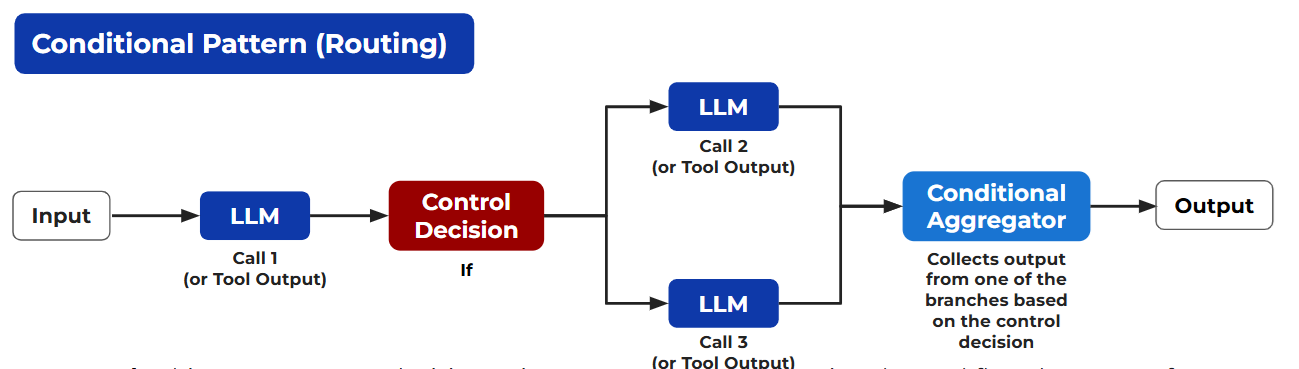

Now that the set of coding questions along with the test cases are available, the next step is to evaluate the questions and provide feedbacks, once the learner submits the solution for the problem.

Their submisssion will then be evaluated against the test cases and feedbacks will be provided.

The Evaluation and Feedback module will evaluate the learner's submissions against the generated test cases, and provide feedback based on evaluation criteria leveraging conditional pattern.

### Define State Object

In [ ]:
# Define the state schema
class EvaluationState(BaseModel):
    question: Dict[str, str]
    test_cases: List[Dict[str, str]]
    user_response: str
    result: str = "pass"  # Binary: "pass" or "fail"
    feedback: str = ""    # Feedback message
    passed_test_cases: List[Dict[str, str]] = []  # Store passed test cases
    failed_test_cases: List[Dict[str, Any]] = []  # Store failed test cases with errors

The `EvaluationState` is a model created using the Pydantic BaseModel that defines the data container for our workflow. It holds,
- The input question,
- The list of test_cases,
- The user_response (learner's code),
- The overall result ("pass" or "fail"), - The generated feedback, and
- Lists to store passed_test_cases and failed_test_cases.

In [ ]:
question

In [ ]:
final_state

In [ ]:
test_case_list = final_state['test_cases']
test_case_list

**Submitted response of the learner for the programming question**

In [ ]:
# Learner's response for question
user_response ="""
def generate_even_squares(input_list):
    # Check if all elements are integers
    if not all(isinstance(x, int) for x in input_list):
        raise ValueError("All elements of the input list must be integers.")

    # Use list comprehension to calculate squares of even numbers
    squared_evens = [x**2 for x in input_list if x % 2 == 0]

    return squared_evens
  """

In [ ]:
print(user_response)

### Define Workflow Node

#### User Response Evaluation Node

In [ ]:
class EvaluationResult(BaseModel):
    is_correct: bool
    error_message: str

`EvaluationResult` defines a data structure with two fields:
- is_correct (true/false) and
- error_message.

It's used to standardize the output of `Evaluate user response Node`.It defines the strict structure we expect back from the LLM when it evaluates the user code against the test case.



In [ ]:
#  Evaluate user response Node
def evaluate_user_response(state: EvaluationState, config: RunnableConfig) -> Dict[str, Any]:
    """Evaluate user code against all test cases using LLM for semantic validation."""
    print("--- EVALUATING USER RESPONSE ---")
    evaluation_prompt = ChatPromptTemplate.from_template("""
You are a programming evaluator. Given the following:
- Problem: {problem}
- User Code: {user_code}
- Test Input: {test_input}
- Expected Output: {expected_output}
- Test Case Type: {testcase_type}
- Difficulty: {difficulty}

Analyze the user code and determine if it would produce the expected output for the given test input. Consider semantic correctness (e.g., lists with same elements in any order if order doesn't matter, appropriate error handling like ValueError).
Return a JSON object with the following fields:
- is_correct: true/false
- error_message: If incorrect, explain why
""")
    state.passed_test_cases = []
    state.failed_test_cases = []

    for test_case in state.test_cases:
        test_input = test_case["input"]
        expected_output = test_case["expected_output"]
        testcase_type = test_case["testcase_type"]
        difficulty = test_case["difficulty"]

        prompt_input = {
            "problem": state.question["problem"],
            "user_code": state.user_response,
            "test_input": test_input,
            "expected_output": expected_output,
            "testcase_type": testcase_type,
            "difficulty": difficulty
        }
        evaluation_chain = evaluation_prompt | llm.with_structured_output(EvaluationResult)
        try:
            eval_result = evaluation_chain.invoke(prompt_input)
            detail = {"test_case": test_case, "error": "", "actual_output": "N/A"}
            if eval_result.is_correct:
                state.passed_test_cases.append(test_case)
            else:
                detail["error"] = eval_result.error_message
                state.failed_test_cases.append(detail)
        except Exception as e:
            detail = {"test_case": test_case, "error": f"LLM evaluation failed: {str(e)}", "actual_output": "N/A"}
            state.failed_test_cases.append(detail)

    state.result = "fail" if state.failed_test_cases else "pass"
    return state.model_dump()

The `evaluate_user_response` node is the crucial step after receiving the user's code and test cases. Its primary purpose is to evaluate the user's code against each provided test case.

- It retrieves the question, test_cases, and user_response from the input state.
- It uses a ChatPromptTemplate instructing the LLM to act as a programming evaluator, analyze the user code with a specific test input and expected output, and consider semantic correctness.
- It leverages llm.with_structured_output (EvaluationResult) to ensure the LLM's response for each test case adheres strictly to the EvaluationResult schema (is_correct and error_message). This is vital for determining which test cases passed or failed.
- Upon evaluation of all test cases, it prints the results and updates the state with lists of passed_test_cases and failed_test_cases, and sets the overall result to "pass" or "fail". It returns the updated state as a dictionary.
- Basic error handling is included; if the LLM call for a specific test case fails, it records an error message and marks the test case as failed.

#### Success Feedback Node

In [ ]:
def success_feedback(state: EvaluationState, config: RunnableConfig) -> Dict[str, Any]:
    """Generate feedback for passed cases using LLM."""
    print("--- GENERATING SUCCESS FEEDBACK ---")
    success_prompt = ChatPromptTemplate.from_template("""
You are a programming tutor. The user’s Python function passed all test cases for:
Problem: {problem}
Sample Input: {sample_input}
Sample Output: {sample_output}
User's Code: {user_code}

Generate concise, positive feedback (under 80 words) highlighting what they did well (e.g., edge cases, input validation).
""")
    prompt_input = {
        "problem": state.question["problem"],
        "sample_input": state.question["sample_input"],
        "sample_output": state.question["sample_output"],
        "user_code": state.user_response
    }
    feedback_chain = success_prompt | llm
    state.feedback = feedback_chain.invoke(prompt_input).content
    return state.model_dump()



Above code defines a workflow node called `success_feedback`. Its purpose is to generate positive feedback using an LLM when a user's code passes all test cases. It takes the question details and user code, prompts the LLM to act as a tutor and provide concise positive feedback (under 80 words), and updates the workflow state with the generated feedback.

#### Improvement Feedback Node

In [ ]:
#  Improvement feedback
def improvement_feedback(state: EvaluationState, config: RunnableConfig) -> Dict[str, Any]:
    """Generate detailed feedback for failed cases using LLM."""
    print("--- GENERATING IMPROVEMENT FEEDBACK ---")
    failure_prompt = ChatPromptTemplate.from_template("""
You are a programming tutor. The user’s Python function failed some test cases for:
Problem: {problem}
Sample Input: {sample_input}
Sample Output: {sample_output}
User's Code: {user_code}
Failed Test Cases: {failed_test_cases}

For each failed test case, provide:
- The input and expected output
- The actual output (if available)
- Why it failed
- Specific suggestions for improvement

Keep the feedback concise (under 100 words), focusing on logic errors, edge cases, or input validation.
""")
    failed_test_cases_str = "\n".join(
        f"Input: {detail['test_case']['input']}, Expected: {detail['test_case']['expected_output']}, "
        f"Actual: {detail['actual_output'] or 'None'}, Type: {detail['test_case']['testcase_type']}, "
        f"Difficulty: {detail['test_case']['difficulty']}, Error: {detail['error']}"
        for detail in state.failed_test_cases
    )
    prompt_input = {
        "problem": state.question["problem"],
        "sample_input": state.question["sample_input"],
        "sample_output": state.question["sample_output"],
        "user_code": state.user_response,
        "failed_test_cases": failed_test_cases_str
    }
    feedback_chain = failure_prompt | llm
    state.feedback = feedback_chain.invoke(prompt_input).content
    return state.model_dump()

Above code defines the `improvement_feedback` node. If the user's code fails tests, this node generates detailed feedback using an LLM. It formats the failed test case information, prompts the LLM to provide reasons for failure and suggestions for improvement (under 100 words), and updates the state with this feedback.

**Define Classification Logic**

In [ ]:
### Define conditional logic
def classify_result(state: EvaluationState) -> Literal["pass", "fail"]:
    """Route based on evaluation result."""
    print("--- CLASSIFYING RESULT ---")
    return state.result

`classify_result` is the core of the conditional pattern. It doesn't perform complex processing itself; instead, it acts as a decision-maker based on the output of the evaluate_user_response node.

It reads the result from the current state. It uses simple logic to return "pass" or "fail" based on the state's result field. Crucially, these returned strings must exactly match the keys used in the path map provided to add_conditional_edges later.

### Graph Construction

In [ ]:
workflow = StateGraph(EvaluationState)
workflow.add_node("evaluate_user_response", evaluate_user_response)
workflow.add_node("success_feedback", success_feedback)
workflow.add_node("improvement_feedback", improvement_feedback)

workflow.add_edge(START, "evaluate_user_response")
workflow.add_conditional_edges(
        "evaluate_user_response",
        classify_result,
        {"pass": "success_feedback", "fail": "improvement_feedback"}
)
workflow.add_edge("success_feedback", END)
workflow.add_edge("improvement_feedback", END)
graph= workflow.compile()

Above code block assembles the workflow's structure using the nodes and the conditional logic defined earlier.

- StateGraph(EvaluationState) initializes the graph builder with our state definition.
- add_node() registers each function (evaluate_user_response, success_feedback, improvement_feedback) as a node with a unique string name.
- add_edge(START ,"evaluate_user_response") sets the entry point: the workflow always begins with the evaluation step.
- add_conditional_edges() is the key implementation of the conditional pattern.
 - It specifies that after the evaluate_user_response node finishes, the classify_result function should be executed.
 - The dictionary {"pass": "success_feedback", "fail": "improvement_feedback"} provided tells LangGraph how to proceed based on the string returned by classify_result. For example, if classify_result returns "pass", the workflow transitions to the node named "success_feedback".

-  add_edge(..., END) defines that after either of the feedback nodes complete, the workflow should terminate successfully.
- compile() finalizes the graph structure, making it ready for execution.

In [ ]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

### Workflow Execution

In [ ]:
result =graph.invoke({"question" : question,"test_cases" :test_case_list, "user_response" :user_response })

In [ ]:
# Output results
print(f"Result: {result['result']}")
print(f"Feedback: {result['feedback']}")

# Conclusion

This case study demonstrates how agentic design patterns can be strategically applied to streamline and automate the programming assessment lifecycle using Generative AI.

By decomposing the workflow into three modular components — Question Generation, Test Case Generation, and Evaluation & Feedback — and aligning each with an appropriate design pattern (Sequential, Parallelization, and Conditional respectively), the solution ensures efficiency, scalability, and adaptability.

The Sequential Pattern in the Question Generation module ensures a logical progression and contextual coherence in the creation and validation of programming problems.




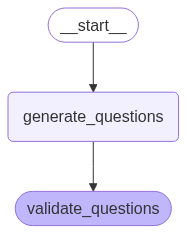

The Parallelization Pattern in the Test Case Generation module enables concurrent processing of diverse test scenarios, significantly reducing latency and increasing robustness.

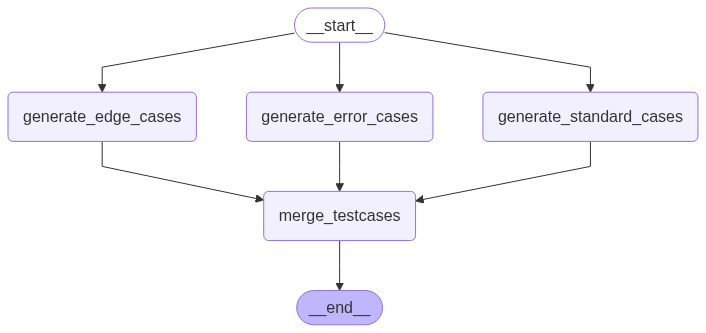

The Conditional Pattern in the Evaluation & Feedback module introduces dynamic decision-making, allowing personalized feedback based on learner performance.

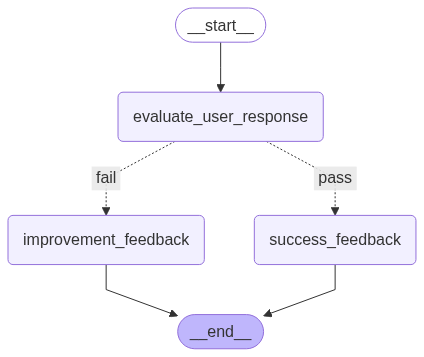

By leveraging LangGraph as the orchestration framework, this agentic workflow architecture not only highlights the power of modular GenAI components but also showcases how flexible design patterns can be used to build intelligent, adaptive systems for real-world education and training challenges.
